# CHEASE fixed-boundary refinement: what changes, what holds, and is it converged?

An EFIT reconstruction fits a free-boundary equilibrium to magnetic measurements. CHEASE solves a different problem: given a **prescribed boundary** and the **profiles** `p'(ψ)` and `FF'(ψ)`, it computes the fixed-boundary Grad-Shafranov equilibrium on a mesh built for stability codes. This notebook answers one question for a packaged VEST reconstruction:

> Given an EFIT equilibrium, what does CHEASE actually change, what is held by the problem definition, and what shows the refined equilibrium is converged and fit to hand to DCON/RDCON/GPEC?

It does **not** claim that CHEASE is a better magnetic reconstruction than EFIT. The refined equilibrium matches no measurement that EFIT did not already fit. What it gains is a cleaner force balance on a controlled mesh.

**Requirements to run this page.** The input-preparation sections (1-6) need only VAFT. Sections 7 onward need a CHEASE executable (`$CHEASEHOME/bin/chease`, or `$CHEASE` / `$CHEASE_EXEC_DIR`); without one they say so and skip. The stored outputs come from a real run (section 7 records the executable). The twelve solves take about five minutes.

## 1. What refinement means here

| | EFIT (free boundary) | CHEASE (fixed boundary) |
|---|---|---|
| boundary | found by fitting coil and plasma currents to the magnetics | **prescribed**: a flux surface of the EFIT map |
| profiles | fitted `p'`, `FF'` basis functions | **given**: the EFIT `p'`, `FF'`, resampled and edge-conditioned |
| normalization | measured `Ip` | **`q` at ψ_N = 0.95 held** (`ncscal = 1`); `Ip` follows |
| mesh | the EFIT R-Z grid | an `NS × NT` finite-element mesh, then mapped to an `nw × nw` EQDSK box |

What the problem definition holds, and what CHEASE recomputes, following the actual input contract (`EXPEQ` plus the namelist):

- **held**: the boundary written to `EXPEQ`; the *shapes* of `p'` and `FF'`; the edge pressure; `q` at the constraint surface; `R0`, `B0`.
- **recomputed**: the interior flux-surface geometry and magnetic axis; the `q` profile everywhere except the constraint surface; the plasma current; `β_p`, `l_i`; rational-surface locations; the metric quantities a stability code reads.

Every difference between the EFIT and CHEASE equilibria below falls into one of three bins: **boundary choice** (section 3), **input preprocessing** (sections 4-5), or **the solve itself** (section 8). The sections keep the bins apart.

In [ ]:
from pathlib import Path
import os

# Resolve against the repository root, not the kernel's cwd: Jupyter starts
# in notebooks/, which would otherwise create a nested notebooks/notebooks/.
_repo_root = Path.cwd()
if _repo_root.name == "notebooks":
    _repo_root = _repo_root.parent
OUTPUT_DIR = Path(os.environ.get(
    "VAFT_DOCS_OUTPUT_DIR", _repo_root / "notebooks" / "outputs" / "docs"
))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
# Select the rendering backend explicitly. In a Jupyter kernel (Jupyter Lab,
# VS Code) ask for the inline backend rather than relying on ipykernel to
# preset MPLBACKEND, which older releases do not do. With no IPython at all
# (a plain `python` run) fall back to headless Agg -- export MPLBACKEND,
# e.g. MPLBACKEND=macosx, to get windows from a script instead.
try:
    _ipython = get_ipython()
except NameError:
    _ipython = None
if _ipython is None:
    os.environ.setdefault("MPLBACKEND", "Agg")
elif "IPKernelApp" in _ipython.config:
    _ipython.run_line_magic("matplotlib", "inline")

import contextlib
from dataclasses import replace
import hashlib
import json
import subprocess
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import vaft
import vaft.omas
from vaft.code.chease import CHEASEConfig, find_chease_executable, prepare_chease_inputs, run_chease
from vaft.data import read_geqdsk
from vaft.data.resources import data_path
from vaft.process.equilibrium import (
    as_equilibrium,
    compare_contours,
    contour_shape_parameters,
    derive_global_descriptors,
)

sample_path = data_path("efit/g039915.00319")
_cleanup = contextlib.ExitStack()
workdir = Path(_cleanup.enter_context(tempfile.TemporaryDirectory(prefix="vaft-chease-notebook-")))

# Problem definition: change these and you are asking CHEASE a different question.
PROBLEM = dict(target_psin=0.993, boundary_smoothing="fft", edge_zero=True, q_constraint_psi_norm=0.95)
# Numerical controls: these should not change the answer, only how well it is computed.
NUMERICS = dict(nw=513, relax=0.5, epslon_exponent=10)
# Section 8 measures CHEASE's own solution, so the refined g-file keeps CHEASE's
# boundary instead of having the EFIT outline pasted back (the production
# default, preserve_boundary_limiter=True; see section 11).
config = CHEASEConfig(
    workdir=workdir / "baseline", create_plot=False, timeout=300,
    preserve_boundary_limiter=False, **PROBLEM, **NUMERICS,
)
executable = find_chease_executable(config)
print(f"source: {sample_path.name}   CHEASE: {executable or 'not found -- sections 7+ will skip'}")
print(f"solver mesh (NS, NT, NPSI, NCHI): {[config.resolved_mesh[k] for k in ('ns', 'nt', 'npsi', 'nchi')]}")

source: g039915.00319   CHEASE: ~/git/chease/src-f90/chease
solver mesh (NS, NT, NPSI, NCHI): [150, 150, 200, 100]


## 2. The input: EFIT reconstruction of VEST 39915 at 319 ms

Every later number is measured against this record, so every change can be traced to one step. `derive_global_descriptors` supplies the geometry, `q` and rational surfaces; `update_equilibrium_derived_profiles` adds `β_p` and `l_i(3)` on the ODS side.

One small function turns a g-file into a row of these descriptors, so that every case below is summarized the same way.

In [ ]:
RATIONAL_Q = (1.0, 1.5, 2.0, 3.0)


def summarize(gfile):
    """One row of the descriptors this notebook compares, from a g-file path."""
    desc = derive_global_descriptors(as_equilibrium(str(gfile)), rational_q=RATIONAL_Q)
    ods = read_geqdsk(str(gfile)).to_omas()
    vaft.omas.update_equilibrium_derived_profiles(ods)
    gq = ods["equilibrium.time_slice.0.global_quantities"]
    psi_n = np.asarray(desc.radial_coordinates["psi_n"].value, dtype=float)
    shear = np.asarray(desc["magnetic_shear"].value, dtype=float)
    residual = vaft.omas.compute_grad_shafranov_residual(ods, time_slice=0)
    row = {
        "R_axis [m]": desc["magnetic_axis_r"].value,
        "Z_axis [m]": desc["magnetic_axis_z"].value,
        "R0 [m]": desc["major_radius"].value,
        "a [m]": desc["minor_radius"].value,
        "kappa": desc["elongation"].value,
        "delta_u": desc["triangularity_upper"].value,
        "delta_l": desc["triangularity_lower"].value,
        "area [m2]": desc["cross_section_area"].value,
        "volume [m3]": desc["volume"].value,
        "Ip [kA]": desc["ip"].value / 1e3,
        "B0 [T]": desc["bt0"].value,
        "q0": desc["q0"].value,
        "q95": desc["q95"].value,
        "q_edge": desc["q_edge"].value,
        "shear@0.95": float(np.interp(0.95, psi_n, shear)),
        "beta_p": float(gq["beta_pol"]),
        "li(3)": float(gq["li_3"]),
        "W_th [J]": desc["thermal_energy"].value,
        "GS residual (median)": float(np.nanmedian(residual.relative)),
    }
    for q in RATIONAL_Q:
        found = [v.value for v in desc.rational_surfaces.get(q, ()) if v.value is not None]
        row[f"psi_N(q={q:g})"] = float(found[0]) if found else np.nan
    return row


efit_row = summarize(sample_path)
print(pd.Series(efit_row, name="EFIT 39915 @ 319 ms").to_string(float_format="{:.5g}".format))

R_axis [m]                0.48125
Z_axis [m]             2.4106e-11
R0 [m]                    0.42997
a [m]                     0.32597
kappa                       1.355
delta_u                   0.39393
delta_l                   0.39393
area [m2]                 0.43647
volume [m3]                1.0819
Ip [kA]                     77.04
B0 [T]                    0.14981
q0                         1.9601
q95                        8.8386
q_edge                     12.955
shear@0.95                 11.796
beta_p                    0.25044
li(3)                     0.63897
W_th [J]                   280.72
GS residual (median)    0.0062269
psi_N(q=1)                    NaN
psi_N(q=1.5)                  NaN
psi_N(q=2)               0.080686
psi_N(q=3)                0.56975


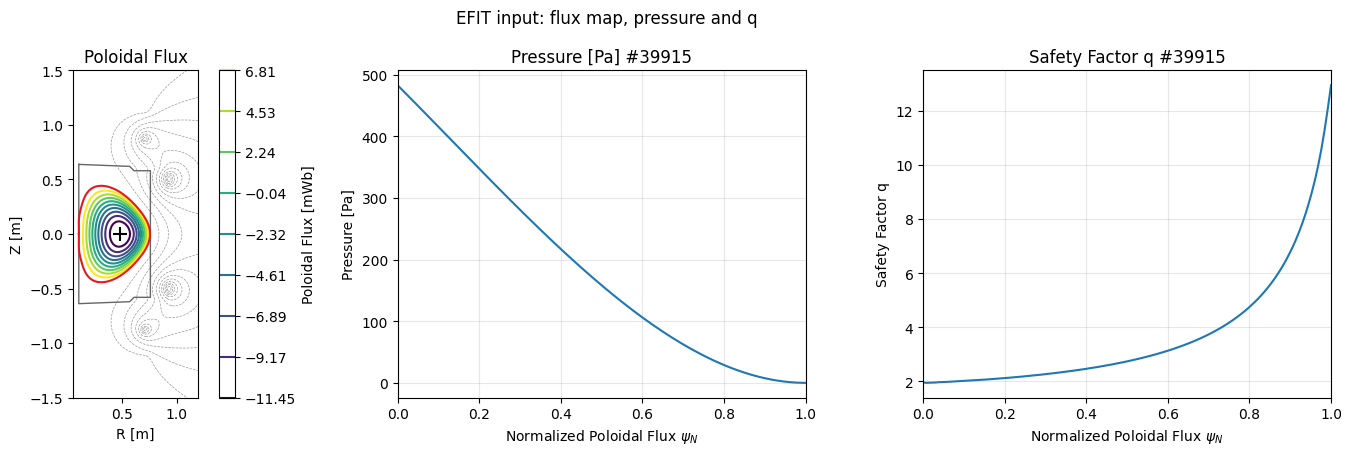

In [ ]:
efit_ods = read_geqdsk(str(sample_path)).to_omas()
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
vaft.omas.plot_equilibrium_field_psi(efit_ods, label="EFIT", ax=axes[0])
for ax, name in zip(axes[1:], ("equilibrium_profile_pressure", "equilibrium_profile_q")):
    vaft.omas.render_plot(name, [efit_ods], label=["EFIT"], coordinate="psi_norm", ax=ax)
fig.suptitle("EFIT input: flux map, pressure and q")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equilibrium-inputs.png", dpi=180, bbox_inches="tight")

## 3. The fixed boundary is a choice: LCFS versus `target_psin`

EFIT's last closed flux surface (ψ_N = 1) can carry a corner where the plasma meets the limiter, or an X-point. CHEASE is given the ψ_N = `target_psin` = 0.993 surface instead, traced from the EFIT flux map. That surface is smooth and lies about millimetres inside. **This changes the problem**: the refined equilibrium is the equilibrium *inside that surface*. It is not a plotting detail.

The contour is then resampled (`boundary_smoothing="fft"`: periodic cubic resampling in the geometric angle onto 128 points) before it is written to `EXPEQ`. Two separations are kept apart below: LCFS → target contour, which is the *problem-definition* change, and target contour → `EXPEQ` boundary, which is the *preprocessing* change. `compare_contours` measures point-to-curve distance, so neither depends on where a contour starts or how densely it is sampled.

                                                  RMS [mm]  max [mm]  perimeter change [mm]  area change [%]  d kappa  d delta_u
LCFS -> target contour (problem definition)         2.8529    5.2425               -18.6335          -1.3795  -0.0038    -0.0042
target contour -> EXPEQ boundary (preprocessing)    0.1286    0.4784                -0.2991          -0.0230   0.0000    -0.0014


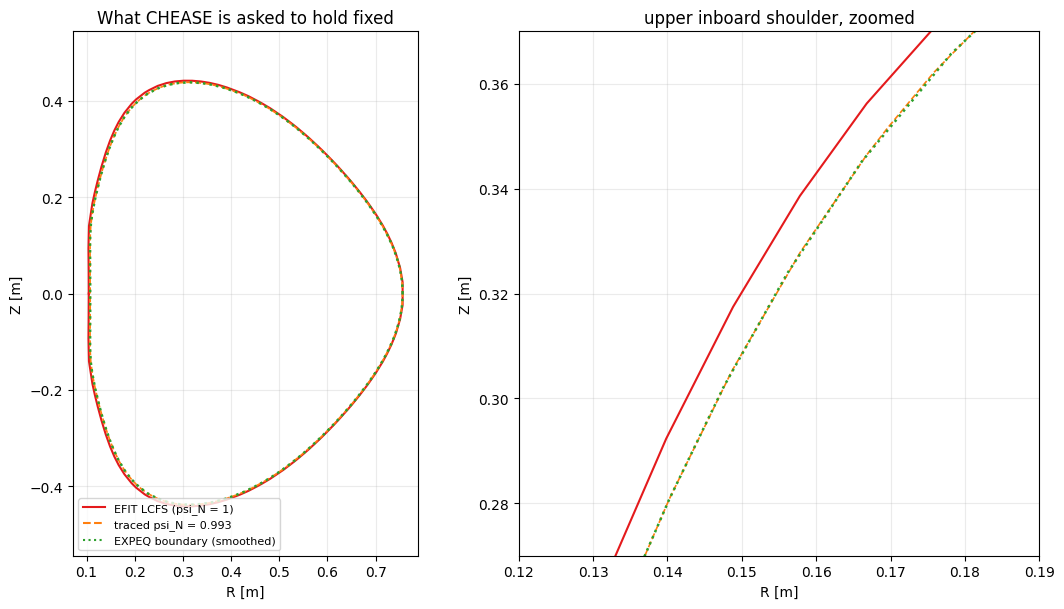

In [ ]:
efit = read_geqdsk(str(sample_path))
inputs = prepare_chease_inputs(sample_path, config)
m = inputs.materialized
lcfs = np.column_stack([efit["RBBBS"], efit["ZBBBS"]])


def shape_row(rz):
    shape = contour_shape_parameters(rz[:, 0], rz[:, 1])
    return {k: shape[k] for k in ("area", "elongation", "triangularity_upper", "triangularity_lower")}


steps = {
    "LCFS -> target contour (problem definition)": (lcfs, m.raw_boundary),
    "target contour -> EXPEQ boundary (preprocessing)": (m.raw_boundary, m.boundary),
}
rows = {}
for name, (a, b) in steps.items():
    sep = compare_contours(a[:, 0], a[:, 1], b[:, 0], b[:, 1])
    sa, sb = shape_row(a), shape_row(b)
    rows[name] = {
        "RMS [mm]": 1e3 * sep["rms"], "max [mm]": 1e3 * sep["max"],
        "perimeter change [mm]": 1e3 * (sep["length_other"] - sep["length_reference"]),
        "area change [%]": 100 * (sb["area"] / sa["area"] - 1),
        "d kappa": sb["elongation"] - sa["elongation"],
        "d delta_u": sb["triangularity_upper"] - sa["triangularity_upper"],
    }
display_steps = pd.DataFrame(rows).T
print(display_steps.round(4).to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 6.2), gridspec_kw={"width_ratios": [1, 1.2]})
for ax in axes:
    vaft.omas.plot_equilibrium_geometry_boundary([efit_ods], label=["EFIT"], ax=ax)
    lcfs_color = ax.lines[0].get_color()
    ax.plot(m.raw_boundary[:, 0], m.raw_boundary[:, 1], "C1--", lw=1.2)
    ax.plot(*np.vstack([m.boundary, m.boundary[:1]]).T, "C2:", lw=1.8)
axes[0].legend(
    [plt.Line2D([], [], color=lcfs_color), plt.Line2D([], [], color="C1", ls="--"), plt.Line2D([], [], color="C2", ls=":")],
    ["EFIT LCFS (psi_N = 1)", f"traced psi_N = {config.target_psin}", "EXPEQ boundary (smoothed)"],
    loc="lower left", fontsize=8,
)
axes[0].set_title("What CHEASE is asked to hold fixed")
# The separation peaks on the inboard shoulders, where the LCFS bends onto the limiter.
axes[1].set_aspect("auto")
axes[1].set_xlim(0.12, 0.19); axes[1].set_ylim(0.27, 0.37)
axes[1].set_title("upper inboard shoulder, zoomed")
fig.tight_layout()

The smoothing step is small next to the boundary choice. The three smoothing modes the adapter offers compare as follows; this needs no CHEASE run. `none` writes the traced contour as is.

In [ ]:
smoothing = {}
for mode in ("fft", "arclength", "none"):
    item = prepare_chease_inputs(
        sample_path, replace(config, workdir=workdir / f"smooth-{mode}", boundary_smoothing=mode)
    ).materialized
    sep = compare_contours(item.raw_boundary[:, 0], item.raw_boundary[:, 1], item.boundary[:, 0], item.boundary[:, 1])
    smoothing[mode] = {"EXPEQ points": len(item.boundary), "RMS [mm]": 1e3 * sep["rms"], "max [mm]": 1e3 * sep["max"]}
print(pd.DataFrame(smoothing).T.round(4).to_string())

           EXPEQ points  RMS [mm]  max [mm]
fft               128.0    0.1286    0.4784
arclength         256.0    0.0511    0.2176
none              219.0    0.0000    0.0000


## 4. The profiles CHEASE receives

`EXPEQ` carries `p'` and `FF'` in CHEASE's normalization and sign pattern. `inputs.materialized` holds the same content in physical units and in the source g-file's own convention, so it can be laid directly over the EFIT profiles. Two steps sit between them:

1. **Resampling** from the EFIT grid onto CHEASE's 401-point ψ_N grid (linear).
2. **Edge conditioning** (`edge_zero=True`): walking in from the separatrix, every `p'` sample whose sign is opposite to the bulk profile (a spline undershoot) is set to zero, and `FF'` is held at its outer neighbour there. The loop starts one sample inside the separatrix, as in the donor script, so the outermost sample is never examined.

The pressure itself enters only through its edge value; `F` does not enter at all. CHEASE rebuilds `F` from `FF'` and `B0`.

edge-conditioned samples: 0 of 401
max |p' written - p' EFIT (linear interp)|: 0 Pa/(Wb/rad)


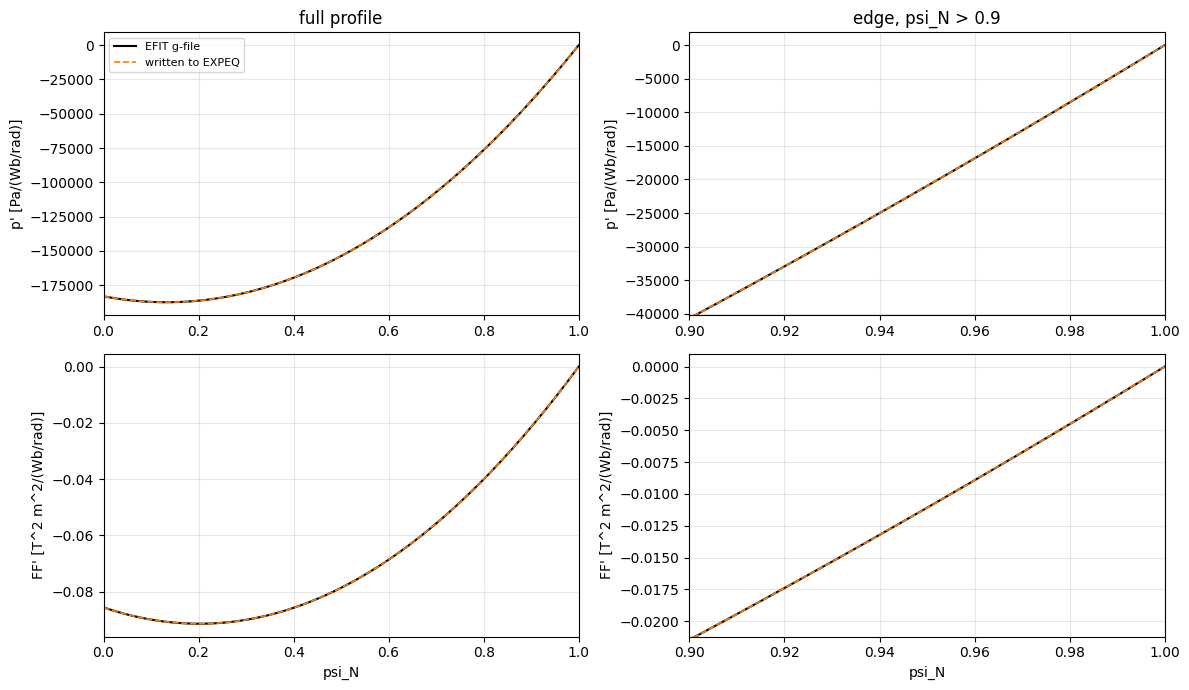

In [ ]:
x_src = np.linspace(0.0, 1.0, len(efit["PPRIME"]))
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for row, (key, given, label, unit) in enumerate((
    ("PPRIME", m.pprime, "p'", "Pa/(Wb/rad)"),
    ("FFPRIM", m.ffprime, "FF'", "T^2 m^2/(Wb/rad)"),
)):
    for col, xlim in enumerate(((0.0, 1.0), (0.9, 1.0))):
        ax = axes[row, col]
        ax.plot(x_src, efit[key], "k-", lw=1.5, label="EFIT g-file")
        ax.plot(m.psi_norm, given, "C1--", lw=1.2, label="written to EXPEQ")
        changed = m.edge_modified
        if changed.any():
            ax.plot(m.psi_norm[changed], given[changed], "rx", label="edge-conditioned")
        ax.set_xlim(*xlim)
        window = (x_src >= xlim[0]) & (x_src <= xlim[1])
        low, high = np.min(efit[key][window]), np.max(efit[key][window])
        ax.set_ylim(low - 0.05 * (high - low), high + 0.05 * (high - low))
        ax.set_ylabel(f"{label} [{unit}]")
        ax.grid(alpha=0.3)
axes[0, 1].set_title("edge, psi_N > 0.9")
axes[0, 0].set_title("full profile")
axes[1, 0].set_xlabel("psi_N"); axes[1, 1].set_xlabel("psi_N")
axes[0, 0].legend(fontsize=8)
fig.tight_layout()

resampling_error = np.max(np.abs(m.pprime_resampled - np.interp(m.psi_norm, x_src, efit["PPRIME"])))
print(f"edge-conditioned samples: {int(m.edge_modified.sum())} of {m.edge_modified.size}")
print(f"max |p' written - p' EFIT (linear interp)|: {resampling_error:.3g} Pa/(Wb/rad)")

## 5. The q constraint

`q_constraint_psi_norm = 0.95` asks CHEASE to match the EFIT `q` on the ψ_N = 0.95 surface, which is the conventional `q95`. CHEASE reads the location as `CSSPEC` on its own radial coordinate `s = sqrt(ψ_N)`, so the adapter writes `CSSPEC = sqrt(0.95)`, taking the root once. With `ncscal = 1`, CHEASE then rescales the current to meet that `q`. So the plasma current is an *output*: holding `q95` does not hold `Ip`, and it does not hold the rest of the `q` profile.

In [ ]:
print(f"constraint surface psi_N = {m.q_constraint_psi_norm}  ->  CSSPEC = {m.csspec:.6f} (= sqrt: {np.sqrt(m.q_constraint_psi_norm):.6f})")
from scipy.interpolate import interp1d

q_cubic = float(interp1d(np.linspace(0, 1, len(efit["QPSI"])), efit["QPSI"], kind="cubic")(0.95))
print(f"QSPEC = {m.qspec:.5f}: EFIT q at psi_N = 0.95 by the adapter's cubic interpolation is {q_cubic:.5f}")
print("  (the sign of QSPEC follows CHEASE's input pattern, section 6)")
print(f"Ip given to CHEASE only as a starting normalization: CURRT = {m.parameters['CURRT']:.5g} (mu0 Ip / R0 B0)")

constraint surface psi_N = 0.95  ->  CSSPEC = 0.974679 (= sqrt: 0.974679)
QSPEC = 8.83374: EFIT q at psi_N = 0.95 by the adapter's cubic interpolation is 8.83374
  (the sign of QSPEC follows CHEASE's input pattern, section 6)
Ip given to CHEASE only as a starting normalization: CURRT = 1.6156 (mu0 Ip / R0 B0)


## 6. Sign conventions: representation, not physics

CHEASE reads the COCOS-02 sign pattern. The adapter flips whichever of ψ, `B0`, `Ip`, `F` and `q` differ, and flips back on output (`output_cocos="input"`). None of this changes the plasma. The table is built from the two manifests the run writes. The third column appears once CHEASE has run (section 7).

In [ ]:
cocos_in = json.loads((inputs.workdir / "chease_cocos_transform.json").read_text())
sign_table = pd.DataFrame({
    "source g-file": cocos_in["input_signs"],
    "CHEASE input": cocos_in["chease_input_signs"],
}).loc[["dpsi_sign", "bcentr_sign", "current_sign", "fpol_sign", "q_sign"]]
print(sign_table.to_string())
print("transform applied to the input:", cocos_in["transform_to_chease_input"])

              source g-file  CHEASE input
dpsi_sign               1.0          -1.0
bcentr_sign             1.0           1.0
current_sign            1.0          -1.0
fpol_sign               1.0           1.0
q_sign                  1.0          -1.0
transform applied to the input: {'bcentr': 1, 'current': -1, 'fpol': 1, 'psi': -1, 'q': -1}


## 7. A known-good baseline solve

Success here means three things, not only a zero exit code: CHEASE exits 0, its own EQDSK (`EQDSK_COCOS_02.OUT`) exists, and the refined g-file parses. `run_chease` already refuses to call a zero exit without that file a success. The provenance recorded here is the minimum needed to reproduce the stored outputs.

In [ ]:
def provenance(executable):
    exe = Path(executable).resolve()
    source_rev = subprocess.run(
        ["git", "-C", str(exe.parent), "rev-parse", "--short", "HEAD"], capture_output=True, text=True
    ).stdout.strip()
    return {
        "executable": exe.name,
        "sha256": hashlib.sha256(exe.read_bytes()).hexdigest()[:16],
        "source revision": source_rev or "unknown (not in a git checkout)",
        "vaft": vaft.__version__,
    }


baseline = None
if executable is None:
    print("CHEASE not found: sections 7-11 are skipped. Everything above is complete without it.")
else:
    started = time.time()
    baseline = run_chease(inputs, config)
    native = baseline.outputs.get("raw", ())
    print(json.dumps(provenance(executable), indent=2))
    print(f"return code {baseline.returncode}, ok = {baseline.ok}, {time.time() - started:.1f} s")
    print(f"native EQDSK: {[p.name for p in native]}  refined g-file: {baseline.refined_geqdsk and baseline.refined_geqdsk.name}")
    if not baseline.ok:
        print(baseline.stderr.strip()[-2000:])
        baseline = None
    else:
        export = json.loads(next(inputs.workdir.glob("*.cocos_export.json")).read_text())
        sign_table["restored output"] = pd.Series(export["after_export_signs"])
        print(sign_table.to_string())

{
  "executable": "chease",
  "sha256": "e79681fb08e6174c",
  "source revision": "0b2a7d2",
  "vaft": "0.7.1"
}
return code 0, ok = True, 23.0 s
native EQDSK: ['EQDSK_COCOS_02.OUT']  refined g-file: g039915_chease.00319
              source g-file  CHEASE input  restored output
dpsi_sign               1.0          -1.0              1.0
bcentr_sign             1.0           1.0              1.0
current_sign            1.0          -1.0              1.0
fpol_sign               1.0           1.0              1.0
q_sign                  1.0          -1.0              1.0


## 8. What the solve changed

The refined boundary is checked against the boundary CHEASE was **given** (the `EXPEQ` boundary), not against the EFIT LCFS: at `target_psin < 1` the two differ by design (section 3). Everything else is compared with the EFIT record of section 2.

In [ ]:
if baseline is not None:
    refined = read_geqdsk(str(baseline.refined_geqdsk))
    held = compare_contours(m.boundary[:, 0], m.boundary[:, 1], refined["RBBBS"], refined["ZBBBS"])
    print(f"refined boundary vs EXPEQ boundary: RMS {1e3 * held['rms']:.3f} mm, max {1e3 * held['max']:.3f} mm")
    chease_row = summarize(baseline.refined_geqdsk)
    table = pd.DataFrame({"EFIT": efit_row, "CHEASE": chease_row})
    table["difference"] = table["CHEASE"] - table["EFIT"]
    table["change [%]"] = (100 * table["difference"] / table["EFIT"].abs()).where(table["EFIT"].abs() > 1e-6)
    print(table.to_string(float_format="{:.5g}".format))
    # ncscal = 1 keeps the shapes of p' and FF' and rescales their amplitude to meet q95.
    grid = np.linspace(0.0, 0.95, 96)  # away from the edge, where both go to zero

    def on_grid(item, key):
        values = np.asarray(item[key], dtype=float)
        return np.interp(grid, np.linspace(0.0, 1.0, values.size), values)

    ratio = {key: float(np.median(on_grid(refined, key) / on_grid(efit, key))) for key in ("PPRIME", "FFPRIM")}
    span = (refined["SIBRY"] - refined["SIMAG"]) / (efit["SIBRY"] - efit["SIMAG"])
    print(f"\nprofile amplitude CHEASE/EFIT (median over psi_N): p' {ratio['PPRIME']:.4f}, FF' {ratio['FFPRIM']:.4f};"
          f" flux span psi_b - psi_a: {span:.4f}")

refined boundary vs EXPEQ boundary: RMS 0.108 mm, max 0.436 mm


                           EFIT     CHEASE  difference  change [%]
R_axis [m]              0.48125     0.4849   0.0036458     0.75756
Z_axis [m]           2.4106e-11 4.6218e-07  4.6216e-07         NaN
R0 [m]                  0.42997    0.43161   0.0016357     0.38042
a [m]                   0.32597    0.32438  -0.0015903    -0.48788
kappa                     1.355     1.3511  -0.0038946    -0.28742
delta_u                 0.39393    0.38089   -0.013035      -3.309
delta_l                 0.39393    0.38089   -0.013035     -3.3091
area [m2]               0.43647    0.43053  -0.0059366     -1.3602
volume [m3]              1.0819     1.0718   -0.010068     -0.9306
Ip [kA]                   77.04     73.729     -3.3108     -4.2974
B0 [T]                  0.14981    0.13883   -0.010976      -7.327
q0                       1.9601     1.9821     0.02198      1.1214
q95                      8.8386     8.8341  -0.0044825   -0.050715
q_edge                   12.955     12.806    -0.14901     -1.

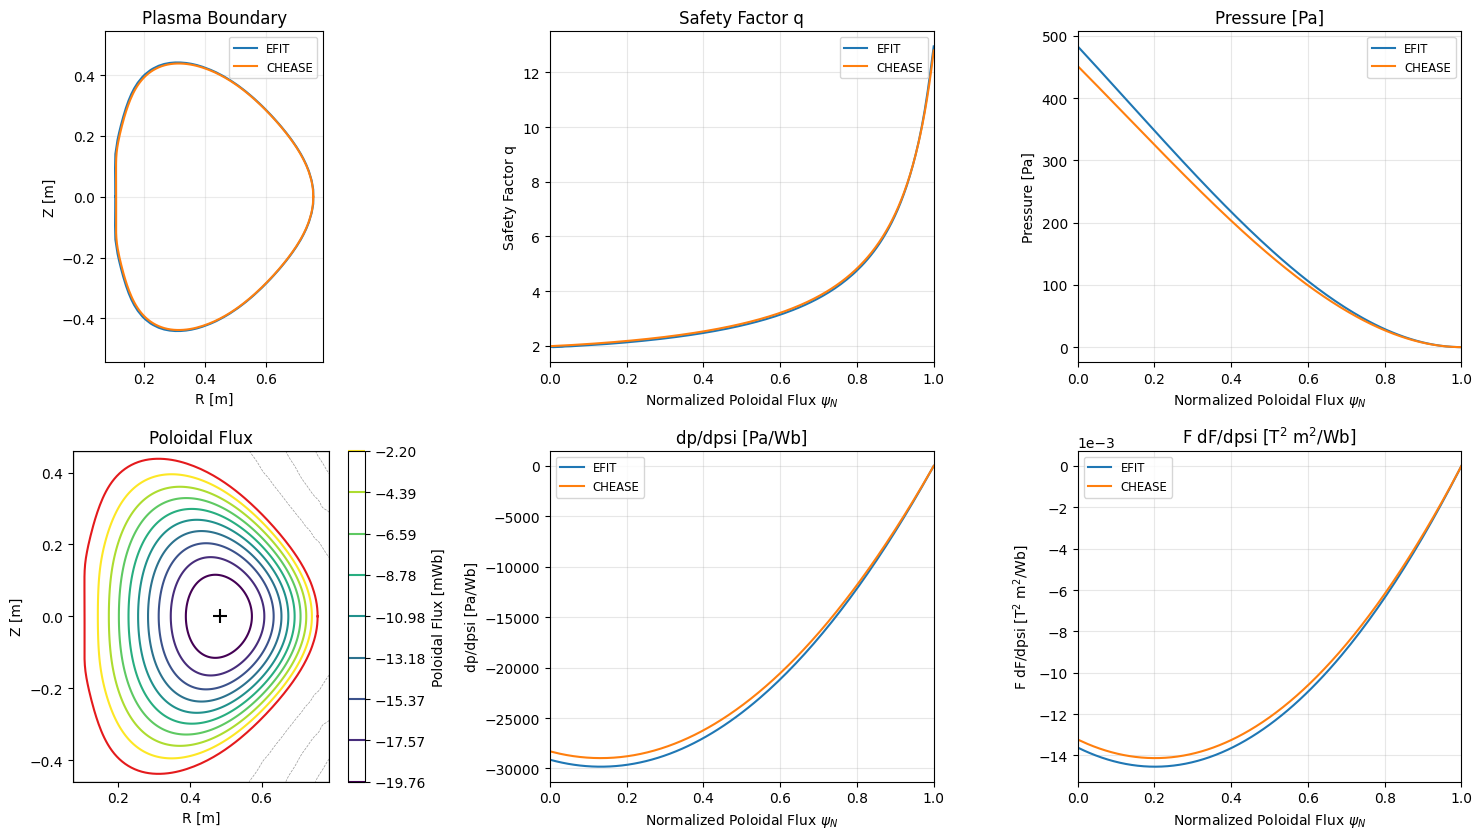

In [ ]:
if baseline is not None:
    chease_ods = read_geqdsk(str(baseline.refined_geqdsk)).to_omas()
    entries, labels = [efit_ods, chease_ods], ["EFIT", "CHEASE"]
    fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
    vaft.omas.plot_equilibrium_geometry_boundary(entries, label=labels, ax=axes[0, 0])
    vaft.omas.plot_equilibrium_field_psi(chease_ods, label="CHEASE", ax=axes[1, 0])
    for ax, name in zip(axes[:, 1:].ravel(), (
        "equilibrium_profile_q", "equilibrium_profile_pressure",
        "equilibrium_profile_pprime", "equilibrium_profile_ffprime",
    )):
        vaft.omas.render_plot(name, entries, label=labels, coordinate="psi_norm", ax=ax)
    fig.tight_layout()

Read the table by the three bins of section 1:

- **Held**: `q95` matches to within the q-evaluation error; the boundary is kept to about 0.1 mm.
- **Boundary choice**: area and volume shrink by about 1% because the plasma now ends at ψ_N = 0.993 (section 3). Section 10 shows that this choice moves `β_p` and `l_i` by under 1%.
- **The solve**: `p'` and `FF'` come back with the same *shape* and a few percent less *amplitude* (the printed ratios). With `ncscal = 1`, CHEASE rescales the profiles until `q95` is met, so the current they drive is whatever that takes. That rescaling, not the boundary choice, is why `Ip`, the pressure, `W_th`, `β_p` and `l_i` all come out several percent lower. The axis moves by a few millimetres. The `q = 2` surface, which sits where `q` is flat near the axis, moves most.
- **Force balance** is what CHEASE should *improve*. The residual in this table is measured on CHEASE's 513×513 output box against EFIT's own 129×129 grid, which section 9 shows is not a like-for-like comparison.

`B0` differs because CHEASE reports the vacuum field at its own `R0` (the geometric centre of the `EXPEQ` boundary), not at the EFIT `RCENTR`. `R·B0` is the invariant.

## 9. Numerical convergence: the solver mesh, not the output grid

`CHEASEConfig` has two resolution controls, and they do different things:

- `nw` is the size of the R-Z box CHEASE **writes** its EQDSK on (`NRBOX = NZBOX`). The equilibrium is not solved there; it is interpolated onto it.
- `ns × nt` is the finite-element mesh the equilibrium **is solved on** (`NPSI × NCHI` is the flux-coordinate mapping built from it).

Each is scanned below, with the other held. The reference-relative change of a quantity X at resolution N is ε_X(N) = |X_N − X_ref| / |X_ref|, where the reference is the finest case. Failed cases stay in the table with their status and are not plotted. No universal "converged" threshold is assumed; the trend is the result.

In [ ]:
TRACK = ["R_axis [m]", "Ip [kA]", "q0", "q95", "beta_p", "li(3)", "volume [m3]", "psi_N(q=2)", "psi_N(q=3)",
         "GS residual (median)"]


def solve(label, **overrides):
    """One CHEASE solve of the baseline problem with some controls changed."""
    case = replace(config, workdir=workdir / label, **overrides)
    started = time.time()
    try:
        case_inputs = prepare_chease_inputs(sample_path, case)
        result = run_chease(case_inputs, case)
    except Exception as error:  # recorded, not hidden
        return {"case": label, "status": f"{type(error).__name__}: {error}"}
    row = {"case": label, "status": "ok" if result.ok else f"failed (exit {result.returncode})",
           "time [s]": round(time.time() - started, 1)}
    if result.ok:
        refined_case = read_geqdsk(str(result.refined_geqdsk))
        b = case_inputs.materialized.boundary
        row["boundary RMS [mm]"] = 1e3 * compare_contours(b[:, 0], b[:, 1], refined_case["RBBBS"], refined_case["ZBBBS"])["rms"]
        row.update({k: v for k, v in summarize(result.refined_geqdsk).items() if k in TRACK})
    return row


def relative_to_last(frame):
    ok = frame[frame["status"] == "ok"]
    reference = ok.iloc[-1]
    return (ok[TRACK[:-1]] - reference[TRACK[:-1]]).abs() / reference[TRACK[:-1]].abs()


mesh_scan = output_scan = None
if baseline is not None:
    mesh_scan = pd.DataFrame([solve(f"ns{n}", ns=n, nt=n) for n in (50, 100, 150, 200)]).set_index("case")
    output_scan = pd.DataFrame([solve(f"nw{n}", nw=n) for n in (129, 257, 513)]).set_index("case")
    print("solver mesh NS = NT (output grid nw = 513):")
    print(mesh_scan.round(5).to_string())
    print("\nreference-relative change, solver mesh (reference NS = NT = 200):")
    print(relative_to_last(mesh_scan).to_string(float_format="{:.1e}".format))
    print(f"\noutput grid nw (solver mesh NS = NT = {config.resolved_mesh['ns']}):")
    print(output_scan.round(5).to_string())

solver mesh NS = NT (output grid nw = 513):
      status  time [s]  boundary RMS [mm]  R_axis [m]  volume [m3]   Ip [kA]       q0      q95   beta_p    li(3)  GS residual (median)  psi_N(q=2)  psi_N(q=3)
case                                                                                                                                                          
ns50      ok       7.0            0.10751      0.4849      1.07185  73.73182  1.98210  8.83411  0.23479  0.59639               0.05479     0.02518     0.55388
ns100     ok      15.4            0.10751      0.4849      1.07185  73.72942  1.98207  8.83411  0.23480  0.59642               0.02874     0.02516     0.55388
ns150     ok      30.2            0.10751      0.4849      1.07185  73.72939  1.98207  8.83411  0.23480  0.59642               0.01238     0.02516     0.55388
ns200     ok      54.3            0.10751      0.4849      1.07185  73.72940  1.98207  8.83411  0.23480  0.59642               0.00473     0.02516     0.55388

r

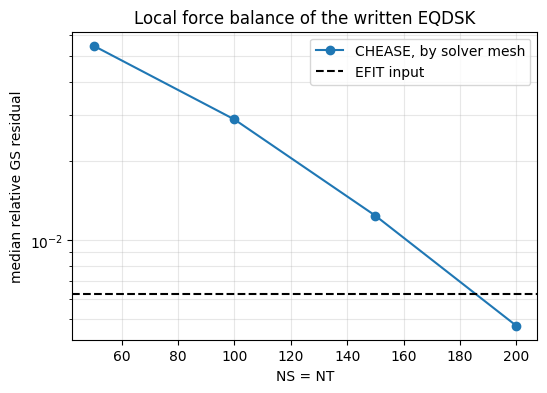

In [ ]:
if mesh_scan is not None:
    fig, ax = plt.subplots(figsize=(6, 4))
    ok = mesh_scan[mesh_scan["status"] == "ok"]
    ax.semilogy([int(c[2:]) for c in ok.index], ok["GS residual (median)"], "o-", label="CHEASE, by solver mesh")
    ax.axhline(efit_row["GS residual (median)"], color="k", ls="--", label="EFIT input")
    ax.set_xlabel("NS = NT"); ax.set_ylabel("median relative GS residual")
    ax.set_title("Local force balance of the written EQDSK"); ax.legend(); ax.grid(alpha=0.3, which="both")

The global descriptors (`q0`, `q95`, `β_p`, `l_i`, `Ip`, volume, axis, rational surfaces) are already converged to about 1e-4 at the coarsest mesh. The **local** force balance is not: the median Grad-Shafranov residual of the written EQDSK roughly halves with each step in `NS = NT`. That residual is what a stability code differentiates. The adapter's default mesh is `NS = NT = 150` for this reason (#885); the older default of 50 left the residual near 5% on the 513 box.

The output grid matters in the opposite direction. The same solution written on a finer box shows a *larger* residual, because interpolating a finite-element solution onto more points exposes more of its element-scale curvature. So the residual only compares like with like at equal grids. On EFIT's own 129×129 grid, the default-mesh CHEASE equilibrium has a lower residual than the EFIT input (the `nw129` row against section 2). On the 513 box it is about twice EFIT's 129-grid value. Choose `nw` for what the downstream code needs and `ns`/`nt` for the force balance.

Rectangular output grids (`NRBOX ≠ NZBOX`) and the computational-domain question belong to #459.

## 10. Boundary-definition sensitivity: `target_psin`

This is not uncertainty in the EFIT reconstruction, and it is not a physics scan (#66 owns those). It shows how much the choice of which near-edge surface to call the boundary moves the quantities a stability calculation reads.

In [ ]:
psin_scan = None
if baseline is not None:
    psin_scan = pd.DataFrame(
        [solve(f"psin{p}", target_psin=p) for p in (0.99, 0.993, 0.995, 0.997)]
    ).set_index("case")
    print(psin_scan.round(5).to_string())

          status  time [s]  boundary RMS [mm]  R_axis [m]  volume [m3]   Ip [kA]       q0      q95   beta_p    li(3)  GS residual (median)  psi_N(q=2)  psi_N(q=3)
case                                                                                                                                                              
psin0.99      ok      19.6            0.10881     0.48497      1.06720  72.33839  2.00314  8.83410  0.23567  0.59781               0.01663         NaN     0.54703
psin0.993     ok      24.8            0.10751     0.48490      1.07185  73.72939  1.98207  8.83411  0.23480  0.59642               0.01238     0.02516     0.55388
psin0.995     ok      24.7            0.10857     0.48485      1.07496  74.68633  1.96785  8.83412  0.23422  0.59547               0.01538     0.04392     0.55846
psin0.997     ok      23.4            0.10941     0.48481      1.07808  75.66601  1.95354  8.83412  0.23363  0.59451               0.01692     0.06186     0.56304


Moving the boundary outward by a few millimetres raises `Ip` and the volume, lowers `q0`, and moves the rational surfaces outward. The `q = 2` surface appears and disappears here, because it sits where `q` is flat near the axis. `q95` does not move, because it is the constraint. `β_p` and `l_i` move by under 1%. That is the point of the scan: any quantity that moves here depends on the boundary definition, and should be reported with the `target_psin` it was computed at.

## 11. Numerical controls are not physics: `relax`

`relax` damps CHEASE's outer iteration. A run that converges should reach the same equilibrium for any `relax`; only the iteration count and runtime should change.

In [ ]:
relax_scan = None
if baseline is not None:
    relax_scan = pd.DataFrame([solve(f"relax{r}", relax=r) for r in (0.2, 0.5, 0.8)]).set_index("case")
    print(relax_scan.round(6).to_string())

         status  time [s]  boundary RMS [mm]  R_axis [m]  volume [m3]    Ip [kA]        q0      q95    beta_p     li(3)  GS residual (median)  psi_N(q=2)  psi_N(q=3)
case                                                                                                                                                                 
relax0.2     ok      15.9           0.107508    0.484896     1.071846  73.729403  1.982071  8.83411  0.234803  0.596417              0.012385     0.02516    0.553878
relax0.5     ok      19.3           0.107508    0.484896     1.071846  73.729386  1.982071  8.83411  0.234803  0.596417              0.012384     0.02516    0.553878
relax0.8     ok      42.1           0.107509    0.484896     1.071846  73.728351  1.982071  8.83411  0.234810  0.596434              0.012381     0.02516    0.553878


**The production g-file is not the one measured here.** The pipeline runs with `preserve_boundary_limiter=True`: after the solve it copies the EFIT `RBBBS/ZBBBS` and limiter back into the refined g-file, so the wall and limiter geometry reach the ODS unchanged. The ψ map, profiles and `q` are CHEASE's. The *boundary outline* in that file is EFIT's ψ_N = 1 curve, however, not CHEASE's ψ_N = 0.993 boundary. Measure shape from CHEASE's own `EQDSK_COCOS_02.OUT`, or run with `preserve_boundary_limiter=False` as this notebook does. Otherwise a shape descriptor reports the EFIT outline whatever CHEASE solved.

## 12. Handing the equilibrium to DCON / RDCON / GPEC

A produced g-file is not sufficient evidence on its own. What this page has shown for the baseline:

In [ ]:
readiness = {
    "sample": sample_path.name,
    "chease_executable": str(executable) if executable else None,
    "execution_mode": "external-binary" if baseline is not None else "input-preparation",
}
if baseline is not None:
    ok_mesh = mesh_scan[mesh_scan["status"] == "ok"]
    readiness.update({
        "solver ran and wrote its EQDSK": bool(baseline.ok),
        "fixed boundary held (RMS mm)": round(1e3 * held["rms"], 3),
        "q95 held (EFIT -> CHEASE)": [round(efit_row["q95"], 4), round(chease_row["q95"], 4)],
        "Ip re-derived (kA)": [round(efit_row["Ip [kA]"], 2), round(chease_row["Ip [kA]"], 2)],
        "q0 / shear@0.95": [round(chease_row["q0"], 4), round(chease_row["shear@0.95"], 4)],
        "rational surfaces psi_N (q=2, 3)": [round(chease_row["psi_N(q=2)"], 4), round(chease_row["psi_N(q=3)"], 4)],
        "beta_p / li(3)": [round(chease_row["beta_p"], 4), round(chease_row["li(3)"], 4)],
        "GS residual median: EFIT (129 grid) / CHEASE on 129 / CHEASE on 513": [
            round(efit_row["GS residual (median)"], 4),
            round(float(output_scan.loc["nw129", "GS residual (median)"]), 4),
            round(chease_row["GS residual (median)"], 4)],
        "global descriptors converged over NS=50..200 (max rel. change)": float(
            relative_to_last(mesh_scan)[["q0", "q95", "beta_p", "li(3)"]].max().max()),
        "edge-conditioned p' samples": int(m.edge_modified.sum()),
    })
(OUTPUT_DIR / "equilibrium-readiness.txt").write_text(json.dumps(readiness, indent=2, default=str) + "\n")
print(json.dumps(readiness, indent=2, default=str))

{
  "sample": "g039915.00319",
  "chease_executable": "~/git/chease/src-f90/chease",
  "execution_mode": "external-binary",
  "solver ran and wrote its EQDSK": true,
  "fixed boundary held (RMS mm)": 0.108,
  "q95 held (EFIT -> CHEASE)": [
    8.8386,
    8.8341
  ],
  "Ip re-derived (kA)": [
    77.04,
    73.73
  ],
  "q0 / shear@0.95": [
    1.9821,
    11.3976
  ],
  "rational surfaces psi_N (q=2, 3)": [
    0.0252,
    0.5539
  ],
  "beta_p / li(3)": [
    0.2348,
    0.5964
  ],
  "GS residual median: EFIT (129 grid) / CHEASE on 129 / CHEASE on 513": [
    0.0062,
    0.0037,
    0.0124
  ],
  "global descriptors converged over NS=50..200 (max rel. change)": 4.6475486236574114e-05,
  "edge-conditioned p' samples": 0
}


In words: the solve ran and wrote a valid EQDSK. It held the boundary it was given and the `q95` it was asked to hold. It rescaled the profile amplitudes and re-derived the current and the interior, and its global descriptors are converged with respect to the solver mesh. At equal grids its local force balance is better than the EFIT input's. What a stability code should additionally be told is the `target_psin` (section 10: it moves the rational surfaces) and the solver mesh (section 9).

`linear_ideal_stability_analysis_with_dcon.ipynb` takes it from here. The DCON/RDCON/GPEC runs themselves are out of scope for this page.

## Cleanup

The work directory is released. Every file in it is regenerable from the packaged sample and the configuration above.

In [ ]:
if workdir.exists():
    _size_mb = sum(p.stat().st_size for p in workdir.rglob("*") if p.is_file()) / 1e6
    print(f"releasing the work directory ({_size_mb:.1f} MB)")
_cleanup.close()
print(f"removed: {not workdir.exists()}")

releasing the work directory (196.8 MB)
removed: True
